# Import Libaries And Datasets

In [25]:
# import the necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [26]:
# read the csv file 
df = pd.read_csv("data/cardio_train.csv", sep=";")

In [27]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


# Perform Exploratory Data Analysis

In [28]:
# Drop id
df = df.drop(columns = 'id')

In [29]:
# since the age is given in days, we convert it into years
df['age'] = df['age']/365

In [30]:
# Statistical summary of the dataframe
df.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,53.339358,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,6.759594,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,29.583562,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.394521,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,53.980822,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,58.430137,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,64.967123,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


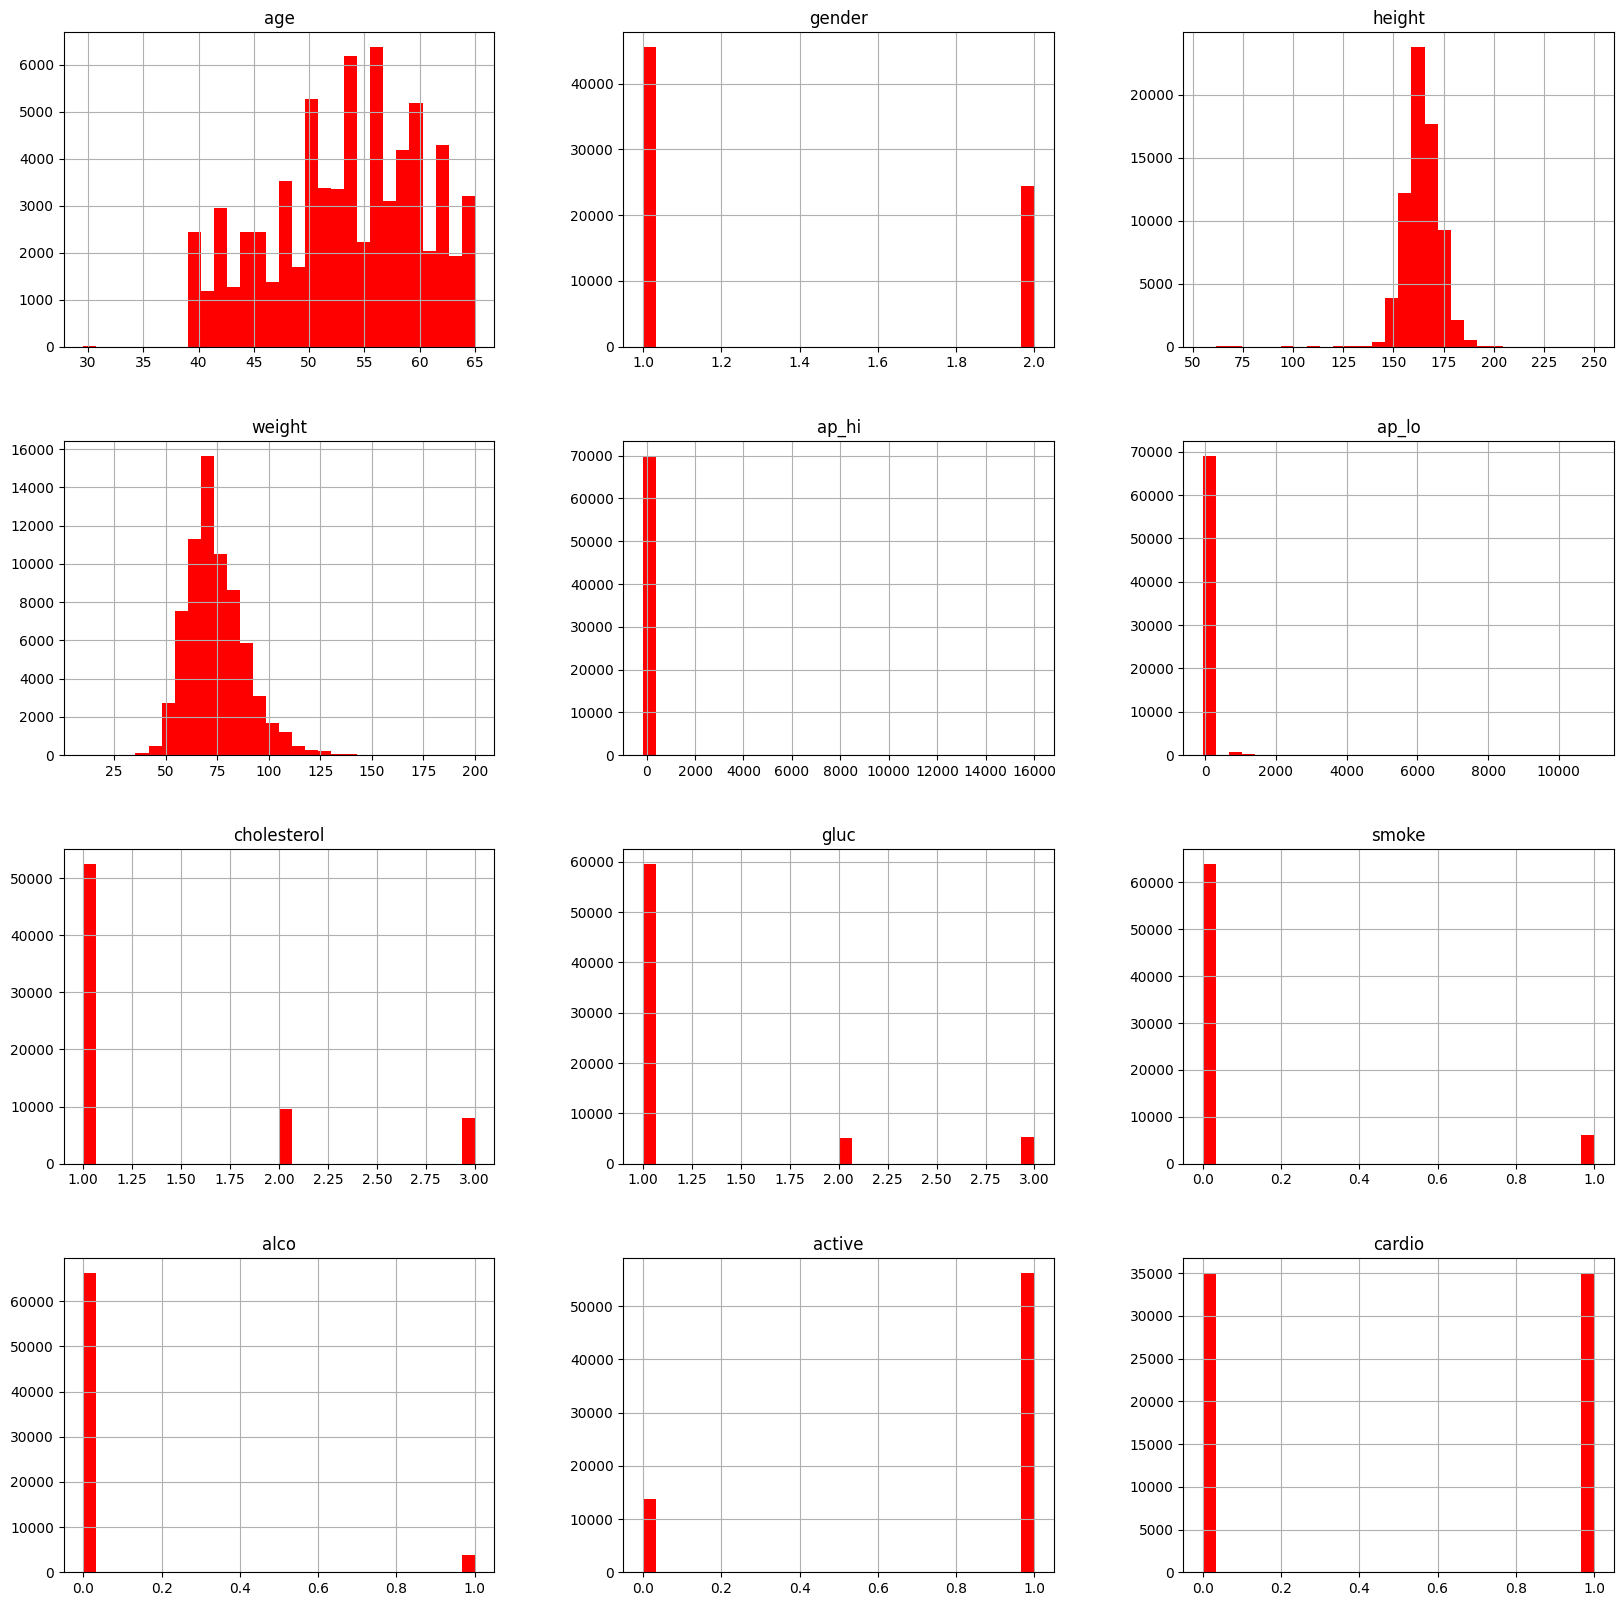

In [31]:
df.hist(bins = 30, figsize = (20,20), color = 'r')
plt.show()

In [32]:
# get the correlation matrix
corr_matrix = df.corr()
corr_matrix

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
age,1.000000,-0.022811,-0.081515,0.053684,0.020764,0.017647,0.154424,0.098703,-0.047633,-0.029723,-0.009927,0.238159
gender,-0.022811,1.000000,0.499033,0.155406,0.006005,0.015254,-0.035821,-0.020491,0.338135,0.170966,0.005866,0.008109
height,-0.081515,0.499033,1.000000,0.290968,0.005488,0.006150,-0.050226,-0.018595,0.187989,0.094419,-0.006570,-0.010821
weight,0.053684,0.155406,0.290968,1.000000,0.030702,0.043710,0.141768,0.106857,0.067780,0.067113,-0.016867,0.181660
ap_hi,0.020764,0.006005,0.005488,0.030702,1.000000,0.016086,0.023778,0.011841,-0.000922,0.001408,-0.000033,0.054475
ap_lo,0.017647,0.015254,0.006150,0.043710,0.016086,1.000000,0.024019,0.010806,0.005186,0.010601,0.004780,0.065719
cholesterol,0.154424,-0.035821,-0.050226,0.141768,0.023778,0.024019,1.000000,0.451578,0.010354,0.035760,0.009911,0.221147
gluc,0.098703,-0.020491,-0.018595,0.106857,0.011841,0.010806,0.451578,1.000000,-0.004756,0.011246,-0.006770,0.089307
smoke,-0.047633,0.338135,0.187989,0.067780,-0.000922,0.005186,0.010354,-0.004756,1.000000,0.340094,0.025858,-0.015486
alco,-0.029723,0.170966,0.094419,0.067113,0.001408,0.010601,0.035760,0.011246,0.340094,1.000000,0.025476,-0.007330


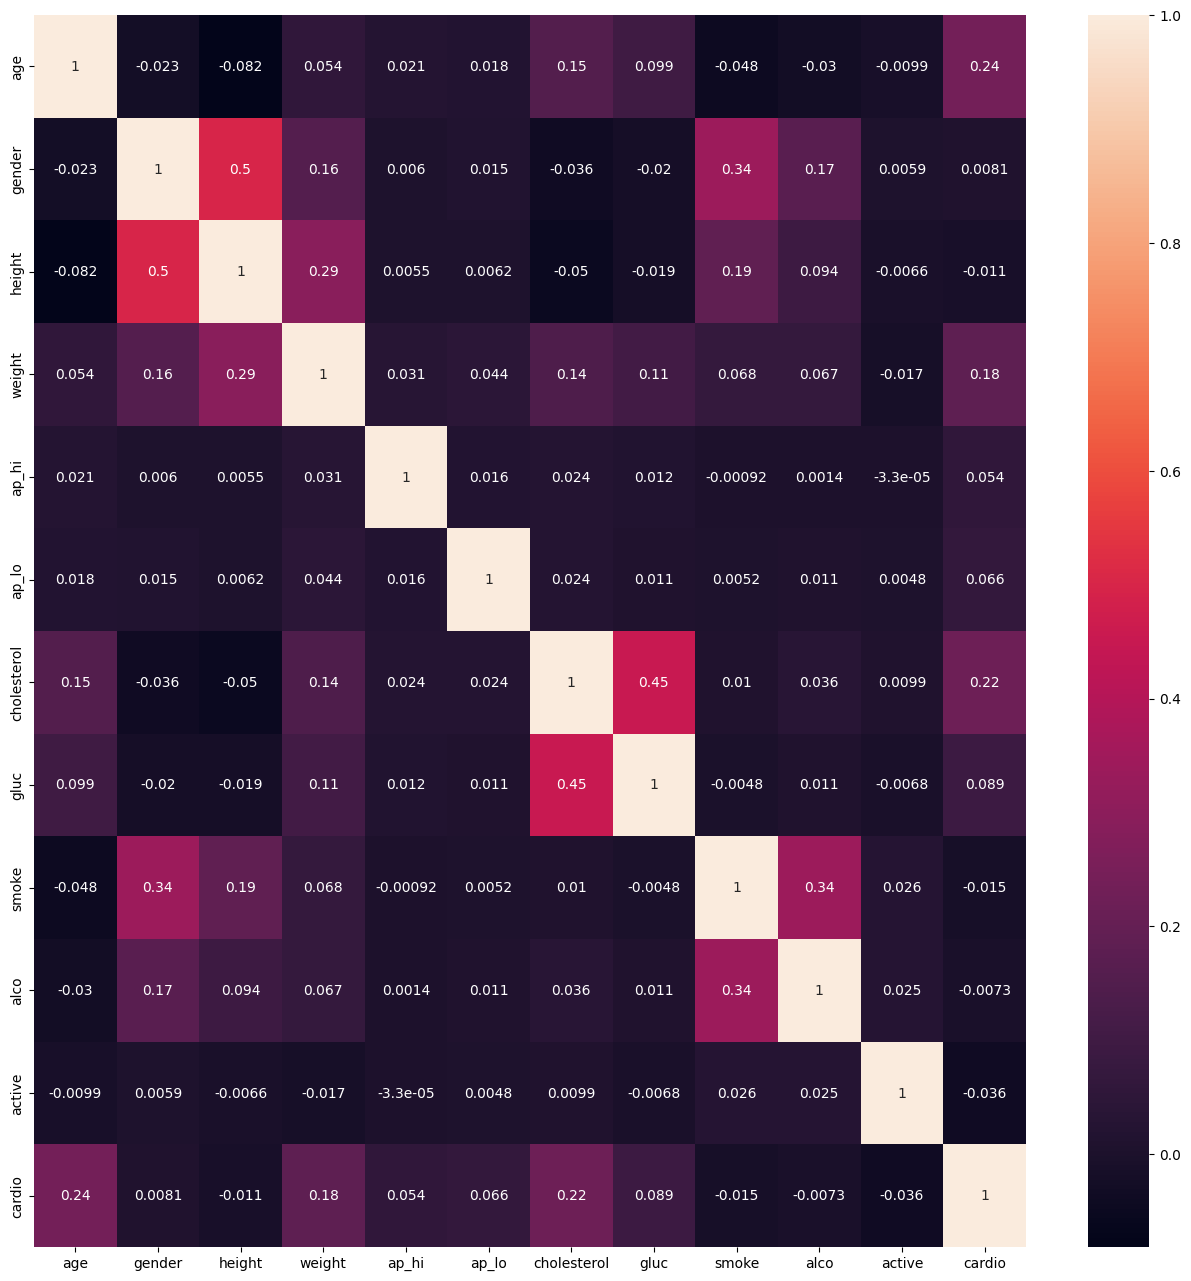

In [33]:
# plotting the correlation matrix
plt.figure(figsize = (16,16))
sns.heatmap(corr_matrix, annot = True)
plt.show()

# Create Training And Testing Dataset

In [34]:
# split the dataframe into target and features
y = df['cardio']
X = df.drop(columns =['cardio'])

In [35]:
X.shape

(70000, 11)

In [36]:
y.shape

(70000,)

In [37]:
#spliting the data in to test and train sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [38]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((56000, 11), (56000,), (14000, 11), (14000,))

In [39]:
# see schule of the data
X_train

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active
62820,60.128767,1,170,68.0,150,90,1,1,0,0,1
852,49.827397,1,158,69.0,120,80,1,1,0,0,1
23261,54.224658,1,163,110.0,150,80,3,2,0,0,1
56673,49.819178,1,162,66.0,170,90,1,1,0,0,0
46860,46.167123,1,148,50.0,140,100,1,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
33925,55.728767,1,156,74.0,120,80,1,1,0,0,1
28604,43.594521,1,167,99.0,180,1100,2,1,0,0,1
54556,51.989041,1,157,76.0,130,80,1,1,0,0,1
111,57.917808,2,159,78.0,120,80,3,3,0,0,1


# Train An XG-Boost Classifier In SK-Learn

In [40]:
from xgboost import XGBClassifier

In XGBClassifier, the max_depth parameter controls the maximum depth of each decision tree used in the boosting process. Changing this parameter directly affects the complexity, learning capability, and generalization performance of the trained model.

| max_depth    | Training Performance | Test Performance      | Risk         |
| ------------ | -------------------- | --------------------- | ------------ |
| Small (1–2)  | Lower                | May generalize better | Underfitting |
| Medium (3–6) | Better               | Often optimal         | Balanced     |
| Large (10+)  | Very high            | May decrease          | Overfitting  |

In [41]:
# Train an XGBoost classifier model 

xgb_classifier = XGBClassifier(
    objective ='binary:logistic',
    eval_metric = 'error',
    learning_rate = 0.1,
    max_depth = 1,
    n_estimators = 10)
xgb_classifier.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

# Test XGBoost Classifier To Perform Inference

In [42]:
# predict the score of the trained model using the testing dataset
result = xgb_classifier.score(X_test, y_test)
print("Accuracy : {}".format(result))

Accuracy : 0.7131428571428572


In [43]:
# make predictions on the test data
y_predict = xgb_classifier.predict(X_test)
y_predict

array([0, 1, 0, ..., 0, 0, 1], shape=(14000,))

In [44]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_predict))
# precision is the ratio of TP/(TP+FP)
# recall is the ratio of TP/(TP+FN)
# F-beta score can be interpreted as a weighted harmonic mean of the precision and recall
# where an F-beta score reaches its best value at 1 and worst score at 0. 


              precision    recall  f1-score   support

           0       0.68      0.80      0.74      7040
           1       0.76      0.62      0.68      6960

    accuracy                           0.71     14000
   macro avg       0.72      0.71      0.71     14000
weighted avg       0.72      0.71      0.71     14000



<Axes: >

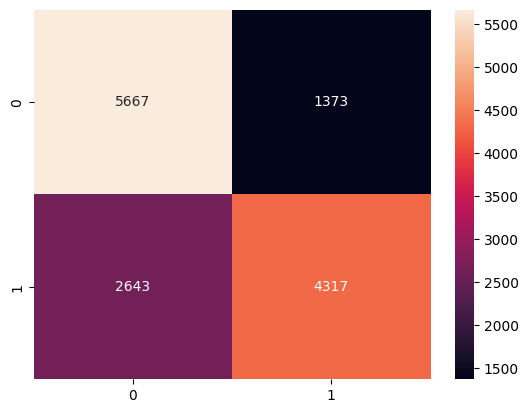

In [45]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_predict)
sns.heatmap(cm, fmt = 'd', annot = True)

This confusion matrix shows the performance of a binary classification model. The rows represent the actual classes, while the columns represent the predicted classes. The matrix values are:

| Actual Class | Predicted 0 | Predicted 1 |
| ------------ | ----------: | ----------: |
| Actual 0     |        5523 |        1411 |
| Actual 1     |        2640 |        4426 |

Interpretation of each value:

True Negatives (TN) = 5523 → The model correctly predicted class 0.
False Positives (FP) = 1411 → The model predicted class 1, but the true class was 0.
False Negatives (FN) = 2640 → The model predicted class 0, but the true class was 1.
True Positives (TP) = 4426 → The model correctly predicted class 1.

From this confusion matrix, we can observe:
- The model correctly classified many samples from both classes.
- here are still significant classification errors:
    - 1411 false alarms (false positives)
    - 2640 missed positive cases (false negatives)

You can also compute important evaluation metrics.
$Accuracy = \frac{TP+TN+FP+FN}{TP+TN} = \frac{4426+5523}{4426+5523+1411+2640} \approx 0.71$
$Precision = \frac{TP+FP}{TP} = \frac{4426+1411}{4426} \approx 0.76$
This means that when the model predicts class 1, it is correct about 76% of the time.
$Recall (Sensitivity) = \frac{TP}{TP+FN} = \frac{4426}{4426+2640} \approx 0.63$
This means the model correctly identifies about 63% of the actual positive cases.

In [ ]:
# Train an XGBoost classifier model 

xgb_classifier = XGBClassifier(
    objective ='binary:logistic',
    eval_metric = 'error',
    learning_rate = 0.1,
    max_depth = 10,
    n_estimators = 10,
    use_label_encoder=False)
xgb_classifier.fit(X_train, y_train)

# make predictions on the test data
y_predict = xgb_classifier.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_predict))

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_predict)
sns.heatmap(cm, fmt = 'd', annot = True)